In [4]:
# ============================================
# SEMANA 12 - AUTOTEC
# Algoritmos de Regresion
# Predecir precio segun kilometraje y year
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from builtins import round as py_round

# ============================================
# CARGAR DATOS ETIQUETADOS DE SEMANA 10
# ============================================

ruta_datos = "/home/jovyan/work/autotec/semana10_final/modelos/datos_etiquetados_kmeans.csv"
df_clusters = pd.read_csv(ruta_datos)

print(f"Total de registros: {len(df_clusters)}")
df_clusters[["marca", "precio", "kilometraje", "depreciacion_estimada", "prediction", "grupo_depreciacion"]].head(10)

Total de registros: 1955


,marca,precio,kilometraje,depreciacion_estimada,prediction,grupo_depreciacion
0,audi,22990000.0,27294.0,842.278806,0,Depreciacion Media
1,audi,22990000.0,11766.0,1953.769015,0,Depreciacion Media
2,audi,23990000.0,1077.0,22254.174397,2,Depreciacion Baja
3,audi,12950000.0,115092.0,112.517703,1,Depreciacion Alta
4,audi,18990000.0,84917.0,223.627499,0,Depreciacion Media
5,audi,23790000.0,26235.0,906.769325,0,Depreciacion Media
6,audi,36990000.0,29450.0,1255.984517,2,Depreciacion Baja
7,audi,54990000.0,1500.0,36635.576282,2,Depreciacion Baja
8,audi,12970000.0,182000.0,71.263345,1,Depreciacion Alta
9,audi,57990000.0,10808.0,5364.973633,2,Depreciacion Baja


In [5]:
# ============================================
# PREPARACION PARA REGRESION
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from builtins import round as py_round

df_reg = df_clusters[["kilometraje", "year", "precio"]].dropna()
df_reg = df_reg[(df_reg["precio"] > 0) & (df_reg["kilometraje"] > 0)]

X = df_reg[["kilometraje", "year"]]
y = df_reg["precio"]

scaler_reg = StandardScaler()
X_scaled = scaler_reg.fit_transform(X)

df_para_regresion = pd.DataFrame(X_scaled, columns=["kilometraje_scaled", "year_scaled"])
df_para_regresion["label_precio"] = y.values

train_reg, test_reg = train_test_split(df_para_regresion, test_size=0.3, random_state=42)

print(f"Datos de entrenamiento: {len(train_reg)}")
print(f"Datos de prueba:        {len(test_reg)}")

Datos de entrenamiento: 1368
Datos de prueba:        587


In [6]:
# ============================================
# MODELO DE REGRESION LINEAL
# ============================================

X_train = train_reg[["kilometraje_scaled", "year_scaled"]]
y_train = train_reg["label_precio"]
X_test  = test_reg[["kilometraje_scaled", "year_scaled"]]
y_test  = test_reg["label_precio"]

# Entrenar el modelo
lr_regresion = LinearRegression()
lr_reg_model = lr_regresion.fit(X_train, y_train)

# Predicciones
predictions_regresion = lr_reg_model.predict(X_test)

# Comparativa precio real vs precio predicho
comparativa = pd.DataFrame({
    "label_precio": y_test.values,
    "prediction":   predictions_regresion.round(0)
})
print("=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===")
print(comparativa.head(10).to_string(index=False))

=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===
 label_precio  prediction
    9400000.0   6759675.0
    7990000.0  17787529.0
   20990000.0  18562646.0
   26390000.0  19898047.0
    7830000.0  15422966.0
   11545000.0  14392730.0
   27480000.0  15323856.0
    8790000.0  12307894.0
   23990000.0  13146329.0
    8950000.0  14610047.0


In [7]:
# ============================================
# EVALUACION DE LA REGRESION
# ============================================

r2   = float(r2_score(y_test, predictions_regresion))
rmse = float(mean_squared_error(y_test, predictions_regresion, squared=False))

print("=" * 50)
print("     EVALUACION DE LA REGRESION (SEMANA 12)     ")
print("=" * 50)
print(f"R2 (Coeficiente de Determinacion): {py_round(r2 * 100, 2)}%")
print(f"RMSE (Error promedio del modelo):  ${py_round(rmse, 0):,}")
print("=" * 50)

print(f"\nInterseccion (Precio base):   ${py_round(float(lr_reg_model.intercept_), 0):,}")
print(f"Coeficiente de 'kilometraje': ${py_round(float(lr_reg_model.coef_[0]), 0):,}")
print(f"Coeficiente de 'year':        ${py_round(float(lr_reg_model.coef_[1]), 0):,}")

     EVALUACION DE LA REGRESION (SEMANA 12)     
R2 (Coeficiente de Determinacion): 10.16%
RMSE (Error promedio del modelo):  $9,516,517.0

Interseccion (Precio base):   $16,162,726.0
Coeficiente de 'kilometraje': $-1,061,590.0
Coeficiente de 'year':        $1,911,805.0


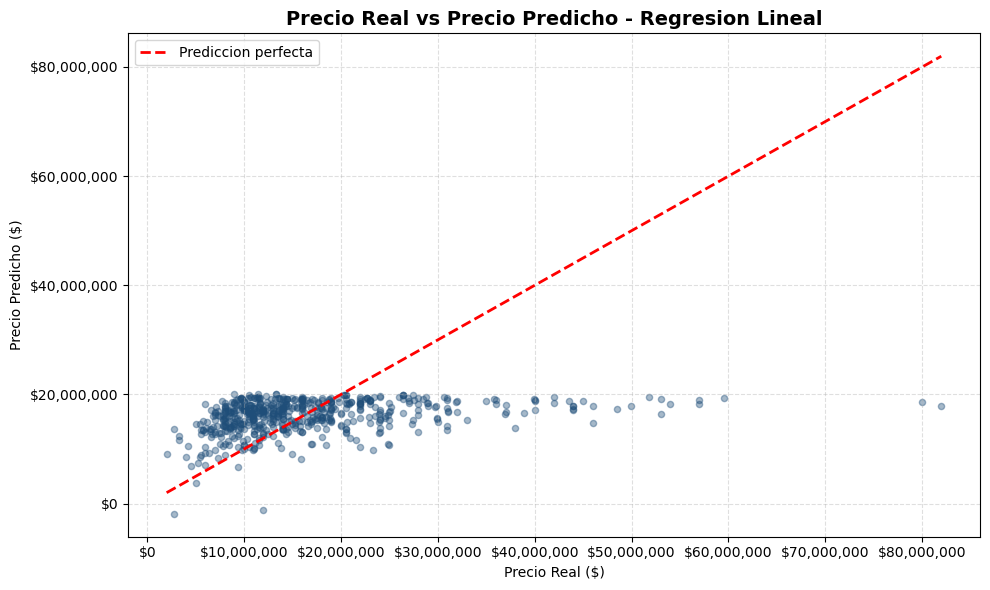

Grafico guardado: regresion_precio.png


In [8]:
# ============================================
# GRAFICO 1: PRECIO REAL VS PRECIO PREDICHO
# ============================================

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_regresion, alpha=0.4, color="#1f4e79", s=20)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=2, label="Prediccion perfecta"
)
plt.title("Precio Real vs Precio Predicho - Regresion Lineal", fontsize=14, fontweight="bold")
plt.xlabel("Precio Real ($)")
plt.ylabel("Precio Predicho ($)")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("regresion_precio.png", dpi=150)
plt.show()
print("Grafico guardado: regresion_precio.png")

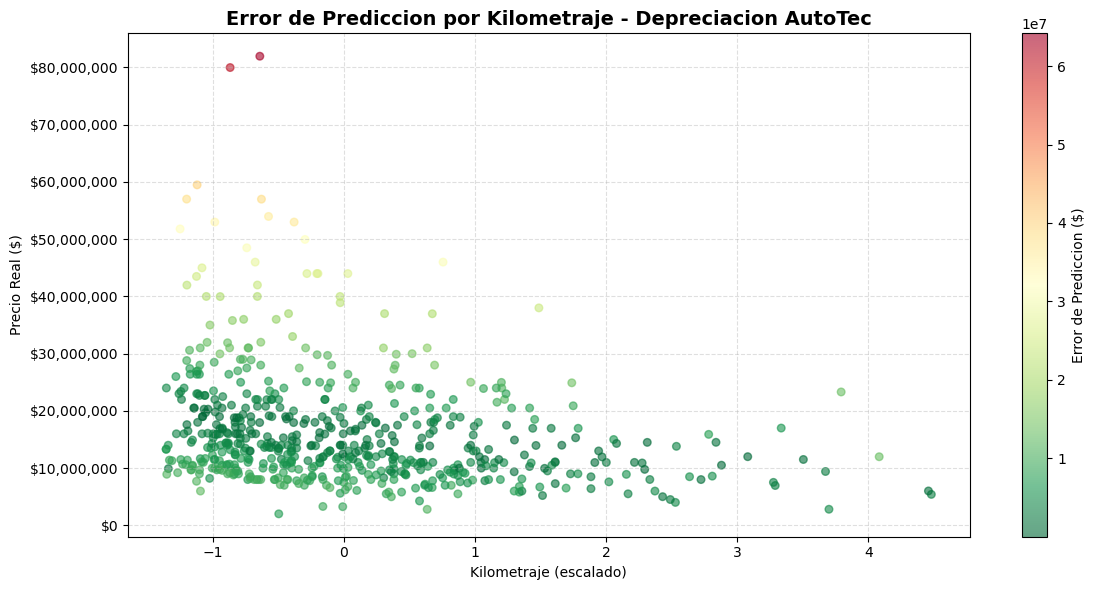

Grafico guardado: error_prediccion_km.png


In [9]:
# ============================================
# GRAFICO 2: ERROR DE PREDICCION POR KM
# ============================================

df_resultado = pd.DataFrame({
    "kilometraje_scaled": test_reg["kilometraje_scaled"].values,
    "precio_real":        y_test.values,
    "precio_predicho":    predictions_regresion,
    "error":              abs(y_test.values - predictions_regresion)
})

plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    df_resultado["kilometraje_scaled"],
    df_resultado["precio_real"],
    c=df_resultado["error"],
    cmap="RdYlGn_r",
    s=30, alpha=0.6
)
plt.colorbar(scatter, label="Error de Prediccion ($)")
plt.title("Error de Prediccion por Kilometraje - Depreciacion AutoTec", fontsize=14, fontweight="bold")
plt.xlabel("Kilometraje (escalado)")
plt.ylabel("Precio Real ($)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("error_prediccion_km.png", dpi=150)
plt.show()
print("Grafico guardado: error_prediccion_km.png")